<a href="https://colab.research.google.com/github/archipelagoing/Situationion/blob/main/SituatiONIONv3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SituatiONION v3: Layer-Wise Causal Tests of Situation Representations

This notebook tests whether GPT-2 XL middle layers transiently encode a situation representation: stable across wording changes but sensitive to changes in agents, recipients, polarity, cause, and time. It replaces the exploratory claims in v2 with controlled measurements and a causal-patching hook.

## Preregistered primary metric

For a base text $x$, a meaning-preserving paraphrase $x^+$, and a meaning-changing counterfactual $x^-$, let $h^{(l)}(x)$ be the pooled residual-stream representation at block $l$. The project-defined situation score is:

$$S_{sit}(l) = E[cos(h^{(l)}(x), h^{(l)}(x^+)) - cos(h^{(l)}(x), h^{(l)}(x^-))].$$

The hypothesis is a reliable local maximum in GPT-2 XL layers 23-26. Geometry and probes locate readable information; activation patching tests whether the state is causally used.

In [2]:
pip install torch transformers scikit-learn pandas matplotlib seaborn

In [3]:
pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


In [1]:
# %pip install torch transformers scikit-learn pandas matplotlib seaborn
from dataclasses import dataclass
from typing import Dict, Sequence

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from transformers import GPT2LMHeadModel, GPT2Tokenizer

sns.set_theme(style='whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32
SEED = 7
np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Using {DEVICE} with {DTYPE}.')

Using cuda with torch.float16.


In [4]:
MODEL_NAME = 'gpt2-xl'
tokenizer = GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
model = GPT2LMHeadModel.from_pretrained(
    MODEL_NAME, torch_dtype=DTYPE, output_hidden_states=True, output_attentions=True
).to(DEVICE).eval()

N_LAYERS = model.config.n_layer
MID = range(17, 32)
CORE_MID = range(23, 27)
print(f'{MODEL_NAME}: {N_LAYERS} blocks; core-middle: {list(CORE_MID)}')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

gpt2-xl: 48 blocks; core-middle: [23, 24, 25, 26]


## Controlled situation triples

The seed examples are pipeline checks, not a publishable dataset. Expand them to hundreds of balanced triples and split by lexical template and entity names. Every triple has a human-readable situation graph: event roles plus a causal or temporal relation.

In [5]:
@dataclass(frozen=True)
class SituationTriple:
    identifier: str
    base: str
    paraphrase: str
    counterfactual: str
    agent: str
    recipient: str
    event: str
    object_name: str
    relation: str
    changed_field: str

SITUATIONS = [
    SituationTriple('transfer_01', 'Leo was locked out, so Maya gave him the key.', 'Because Leo could not enter, Maya handed the key to him.', 'Maya was locked out, so Leo gave her the key.', 'Maya', 'Leo', 'give', 'key', 'cause(locked_out(Leo), give(Maya, Leo, key))', 'agent_recipient_cause'),
    SituationTriple('transfer_02', 'Nora lent Omar the map because he was lost.', 'Omar was lost, and Nora handed him a map.', 'Nora lent Omar the map because she was lost.', 'Nora', 'Omar', 'give', 'map', 'cause(lost(Omar), give(Nora, Omar, map))', 'cause'),
    SituationTriple('transfer_03', 'Iris passed Jules the torch after the lights failed.', 'After the lights went out, Iris handed the torch to Jules.', 'After the lights went out, Jules handed the torch to Iris.', 'Iris', 'Jules', 'give', 'torch', 'after(lights_failed, give(Iris, Jules, torch))', 'agent_recipient'),
    SituationTriple('repair_01', 'Sam repaired the bike because it was broken.', 'Because the bike was broken, Sam fixed it.', 'Sam did not repair the bike even though it was broken.', 'Sam', 'bike', 'repair', 'bike', 'cause(broken(bike), repair(Sam, bike))', 'polarity'),
    SituationTriple('repair_02', 'Ava cleaned the spill after the glass fell.', 'After the glass fell, Ava wiped up the spill.', 'Ava cleaned the spill before the glass fell.', 'Ava', 'spill', 'clean', 'spill', 'after(glass_fell, clean(Ava, spill))', 'temporal_relation'),
    SituationTriple('rescue_01', 'Kai rescued the dog because it was trapped.', 'The dog was trapped, so Kai saved it.', 'The dog rescued Kai because he was trapped.', 'Kai', 'dog', 'rescue', 'dog', 'cause(trapped(dog), rescue(Kai, dog))', 'agent_recipient'),
    SituationTriple('message_01', 'Mina warned Theo because the bridge was unsafe.', 'Because the bridge was unsafe, Mina alerted Theo.', 'Theo warned Mina because the bridge was unsafe.', 'Mina', 'Theo', 'warn', 'bridge', 'cause(unsafe(bridge), warn(Mina, Theo))', 'agent_recipient'),
    SituationTriple('food_01', 'Ravi gave Uma soup because she was ill.', 'Uma was ill, so Ravi brought her soup.', 'Ravi gave Uma soup because he was ill.', 'Ravi', 'Uma', 'give', 'soup', 'cause(ill(Uma), give(Ravi, Uma, soup))', 'cause'),
]
pd.DataFrame([s.__dict__ for s in SITUATIONS])

,identifier,base,paraphrase,counterfactual,agent,recipient,event,object_name,relation,changed_field
0,transfer_01,"Leo was locked out, so Maya gave him the key.","Because Leo could not enter, Maya handed the k...","Maya was locked out, so Leo gave her the key.",Maya,Leo,give,key,"cause(locked_out(Leo), give(Maya, Leo, key))",agent_recipient_cause
1,transfer_02,Nora lent Omar the map because he was lost.,"Omar was lost, and Nora handed him a map.",Nora lent Omar the map because she was lost.,Nora,Omar,give,map,"cause(lost(Omar), give(Nora, Omar, map))",cause
2,transfer_03,Iris passed Jules the torch after the lights f...,"After the lights went out, Iris handed the tor...","After the lights went out, Jules handed the to...",Iris,Jules,give,torch,"after(lights_failed, give(Iris, Jules, torch))",agent_recipient
3,repair_01,Sam repaired the bike because it was broken.,"Because the bike was broken, Sam fixed it.",Sam did not repair the bike even though it was...,Sam,bike,repair,bike,"cause(broken(bike), repair(Sam, bike))",polarity
4,repair_02,Ava cleaned the spill after the glass fell.,"After the glass fell, Ava wiped up the spill.",Ava cleaned the spill before the glass fell.,Ava,spill,clean,spill,"after(glass_fell, clean(Ava, spill))",temporal_relation
5,rescue_01,Kai rescued the dog because it was trapped.,"The dog was trapped, so Kai saved it.",The dog rescued Kai because he was trapped.,Kai,dog,rescue,dog,"cause(trapped(dog), rescue(Kai, dog))",agent_recipient
6,message_01,Mina warned Theo because the bridge was unsafe.,"Because the bridge was unsafe, Mina alerted Theo.",Theo warned Mina because the bridge was unsafe.,Mina,Theo,warn,bridge,"cause(unsafe(bridge), warn(Mina, Theo))",agent_recipient
7,food_01,Ravi gave Uma soup because she was ill.,"Uma was ill, so Ravi brought her soup.",Ravi gave Uma soup because he was ill.,Ravi,Uma,give,soup,"cause(ill(Uma), give(Ravi, Uma, soup))",cause


In [6]:
def run_text(text: str) -> Dict[str, object]:
    inputs = tokenizer(text, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, output_attentions=True, use_cache=False)
    return {
        'text': text,
        'input_ids': inputs.input_ids.detach().cpu(),
        # Index 0 is embeddings. Index l + 1 is output after Transformer block l.
        'hidden_states': tuple(x.detach().float().cpu() for x in outputs.hidden_states),
        'attentions': tuple(x.detach().float().cpu() for x in outputs.attentions),
        'logits': outputs.logits.detach().float().cpu(),
    }

def layer_vector(run: Dict[str, object], block_layer: int) -> np.ndarray:
    # Mean pooling avoids the final-token-only confound in differently worded inputs.
    return run['hidden_states'][block_layer + 1][0].mean(dim=0).numpy()

def cosine(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def cache_runs(situations: Sequence[SituationTriple]):
    return {s.identifier: {
        'base': run_text(s.base),
        'paraphrase': run_text(s.paraphrase),
        'counterfactual': run_text(s.counterfactual),
    } for s in situations}

RUNS = cache_runs(SITUATIONS)

,layer,paraphrase_similarity,counterfactual_similarity,situation_score,situation_score_se
15,15,0.995765,0.99772,-0.001955,0.000878


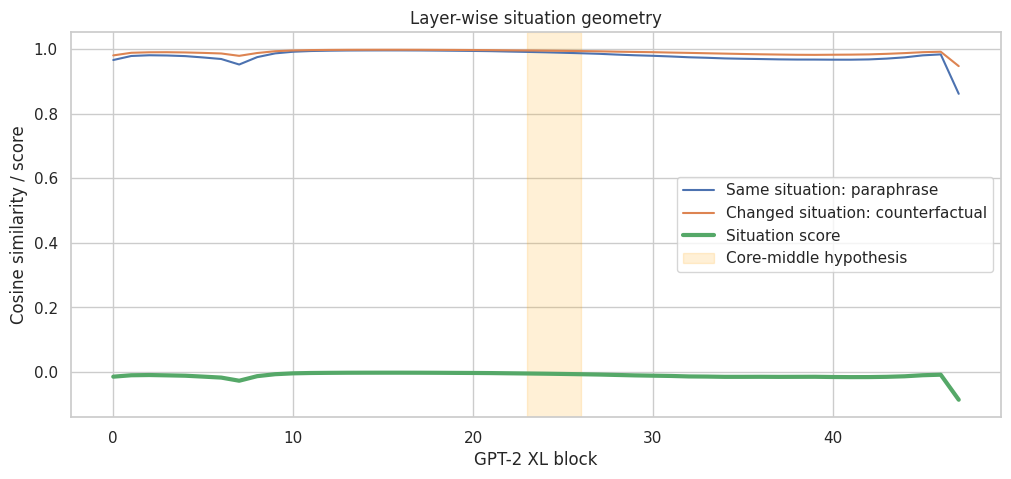

In [7]:
def situation_curve(situations, runs) -> pd.DataFrame:
    rows = []
    for layer in range(N_LAYERS):
        paraphrase, counterfactual = [], []
        for situation in situations:
            item = runs[situation.identifier]
            base = layer_vector(item['base'], layer)
            paraphrase.append(cosine(base, layer_vector(item['paraphrase'], layer)))
            counterfactual.append(cosine(base, layer_vector(item['counterfactual'], layer)))
        difference = np.subtract(paraphrase, counterfactual)
        rows.append({
            'layer': layer,
            'paraphrase_similarity': np.mean(paraphrase),
            'counterfactual_similarity': np.mean(counterfactual),
            'situation_score': np.mean(difference),
            'situation_score_se': np.std(difference, ddof=1) / np.sqrt(len(difference)),
        })
    return pd.DataFrame(rows)

scores = situation_curve(SITUATIONS, RUNS)
display(scores.loc[[scores.situation_score.idxmax()]])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(scores.layer, scores.paraphrase_similarity, label='Same situation: paraphrase')
ax.plot(scores.layer, scores.counterfactual_similarity, label='Changed situation: counterfactual')
ax.plot(scores.layer, scores.situation_score, linewidth=3, label='Situation score')
ax.axvspan(min(CORE_MID), max(CORE_MID), color='orange', alpha=0.16, label='Core-middle hypothesis')
ax.set(xlabel='GPT-2 XL block', ylabel='Cosine similarity / score', title='Layer-wise situation geometry')
ax.legend(); plt.show()

**Conclusion:**
The paraphrase and counterfactual sentences stay almost equally similar to the original sentence across most GPT-2 XL layers. Because of this, the situation score stays close to zero and does not show a clear peak in layers 23–26. This suggests that, using this mean-pooled cosine similarity method, GPT-2 XL is not clearly separating sentences that describe the same situation from sentences where the situation has been changed.

## Linear probes and attention-span diagnostic

Tenney et al. (2019) locate readable information with a learned scalar mixture, $h = gamma sum_l s_l h_l$ and $s_l = softmax(a)_l$. This notebook instead fits separate linear probes per layer, which makes the depth profile visible. The MSPGT preprint defines attention span as:

$$d_{attn}^{(l,h)} = \frac{1}{T}\sum_{t=1}^{T}\sum_{i=1}^{n} A_{t,i}^{(l,h)}|t-i|.$$

Attention span is descriptive supporting evidence. A probe or attention pattern cannot establish causal use.

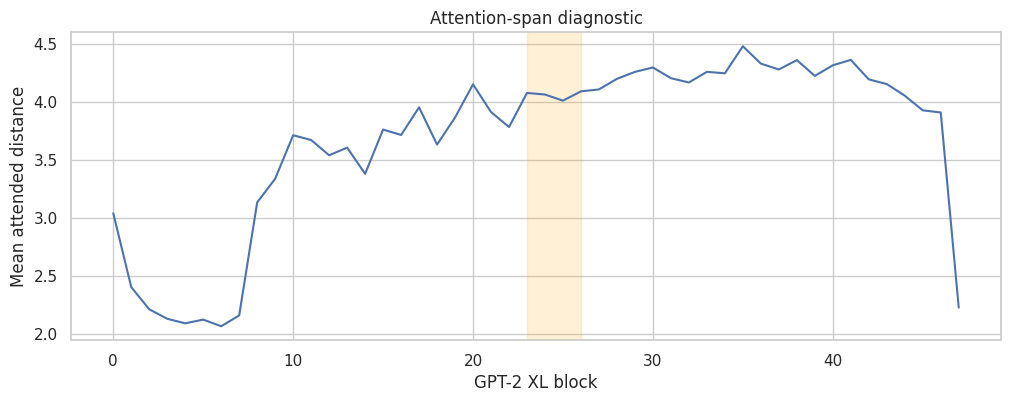

In [8]:
def attention_span(attention: torch.Tensor) -> float:
    # attention: (batch, heads, query_positions, key_positions)
    weights = attention[0]
    positions = torch.arange(weights.shape[-1], dtype=weights.dtype)
    distances = (positions[None, :] - positions[:, None]).abs()
    return float((weights * distances.unsqueeze(0)).sum(dim=-1).mean())

attention_scores = pd.DataFrame([{
    'layer': layer,
    'attention_span': np.mean([attention_span(RUNS[s.identifier]['base']['attentions'][layer]) for s in SITUATIONS]),
} for layer in range(N_LAYERS)])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(attention_scores.layer, attention_scores.attention_span)
ax.axvspan(min(CORE_MID), max(CORE_MID), color='orange', alpha=0.16)
ax.set(xlabel='GPT-2 XL block', ylabel='Mean attended distance', title='Attention-span diagnostic')
plt.show()

def probe_curve(situations, runs, label_name: str) -> pd.DataFrame:
    labels = np.array([getattr(s, label_name) for s in situations])
    y = LabelEncoder().fit_transform(labels)
    min_count = min(np.bincount(y))
    if min_count < 2:
        raise ValueError('Add balanced examples: each probe class needs at least two items.')
    cv = StratifiedKFold(n_splits=min(3, min_count), shuffle=True, random_state=SEED)
    rows = []
    for layer in range(N_LAYERS):
        X = np.stack([layer_vector(runs[s.identifier]['base'], layer) for s in situations])
        accuracy = cross_val_score(LogisticRegression(max_iter=4000, class_weight='balanced'), X, y, cv=cv).mean()
        rows.append({'layer': layer, 'accuracy': accuracy})
    return pd.DataFrame(rows)

# Example after expanding SITUATIONS into a balanced dataset:
# event_probe = probe_curve(SITUATIONS, RUNS, 'event')

**Conclusion: Attention-span diagnostic**

The attention-span curve shows a clear depth-dependent shift from relatively local attention in early layers toward broader contextual attention in middle and later layers. Early layers attend roughly two tokens away on average, while later layers reach approximately four or more tokens away. The strongest transition appears around layers 8–10, followed by a gradual increase through the middle and late network.

The preregistered layers 23–26 lie inside this broader-attention regime, but they do not form a unique peak or transition. Therefore, this figure supports the idea that GPT-2 XL progressively integrates information over larger textual distances, but it does not specifically show that situation representations emerge in layers 23–26. Your notebook correctly treats attention span as descriptive supporting evidence rather than proof of causal representation.

-------
GPT-2 XL exhibits increasing contextual integration with depth. Attention becomes substantially less local after the early layers, but no unique transition is observed within the preregistered core-middle region.
-------


## Causal test: final-position activation patching

The patch replaces the target run's final-position residual state after a chosen block with the donor state at the same position. For a candidate token $y$, measure:

$$Delta_y = log P(y | patch(h_{donor}^{(l)})) - log P(y | h_{target}^{(l)}).$$

Use matched-length prompts at first. Compare core-middle patches against early, late, random, and lexical-match controls.

In [9]:
def next_token_logprob(logits: torch.Tensor, token_text: str) -> float:
    token_ids = tokenizer.encode(token_text, add_special_tokens=False)
    if len(token_ids) != 1:
        raise ValueError(f'Use a single GPT-2 token. {token_text!r} becomes {token_ids}.')
    return float(torch.log_softmax(logits[0, -1].float(), dim=-1)[token_ids[0]].cpu())

def patch_final_position(donor_text: str, target_text: str, block_layer: int, candidate_token: str) -> Dict[str, float]:
    donor_inputs = tokenizer(donor_text, return_tensors='pt').to(DEVICE)
    target_inputs = tokenizer(target_text, return_tensors='pt').to(DEVICE)
    if donor_inputs.input_ids.shape[1] != target_inputs.input_ids.shape[1]:
        raise ValueError('Use matched token lengths for this first causal test.')
    with torch.no_grad():
        donor = model(**donor_inputs, use_cache=False)
        baseline = model(**target_inputs, use_cache=False)
    donor_state = donor.hidden_states[block_layer + 1][:, -1:, :].detach()

    def replace_final_position(module, inputs, output):
        hidden = output[0].clone()
        hidden[:, -1:, :] = donor_state
        return (hidden,) + output[1:]

    handle = model.transformer.h[block_layer].register_forward_hook(replace_final_position)
    try:
        with torch.no_grad():
            patched = model(**target_inputs, use_cache=False)
    finally:
        handle.remove()

    baseline_lp = next_token_logprob(baseline.logits, candidate_token)
    patched_lp = next_token_logprob(patched.logits, candidate_token)
    return {'layer': block_layer, 'baseline_logprob': baseline_lp, 'patched_logprob': patched_lp, 'delta_logprob': patched_lp - baseline_lp}

# Example after selecting matched-token-length prompts and a one-token continuation:
# patch_final_position('Leo has the key and can', 'Leo has no key and can', 24, ' enter')

## Decision rule

Claim a core-middle situation regime only if held-out lexical templates show all four results: (1) a reliable local maximum of $S_{sit}(l)$ in the preregistered band; (2) stronger event-role/discourse probes there than relevant controls; (3) compatible attention-span or relation-head changes; and (4) selective, replicated changes in event-consistent next-token probabilities under patching.

This follows the layer-localization evidence in Jawahar et al. (2019), Tenney et al. (2019), Vig (2019), and Clark et al. (2019), while adopting the causal-interpretability warning emphasized by Rogers et al. (2020) and Ferrando et al. (2024). The discourse target is the microstructure/macrostructure distinction of Kintsch and van Dijk (1978, 1983): entities, events, roles, relations, and global topic rather than word overlap alone.

----
----
----


## Alternative representation diagnostic
Using the same eight triples and cached runs, compare several readouts before expanding the dataset or running probes. The question is whether a readout separates base--paraphrase pairs from base--counterfactual pairs anywhere in the network, not whether it peaks in a preferred layer band. Token selectors are manually specified for this small diagnostic so role swaps, polarity changes, and temporal changes refer to the intended semantic content.

In [10]:
import re

# These spans identify the semantic content to compare in each of the fixed examples.
# The selected token is the final token of the annotated span.
TOKEN_SPANS = {
    'transfer_01': {
        'base': {'changed': 'Maya', 'event': 'gave'},
        'paraphrase': {'changed': 'Maya', 'event': 'handed'},
        'counterfactual': {'changed': 'Leo', 'event': 'gave'},
    },
    'transfer_02': {
        'base': {'changed': 'he', 'event': 'lent'},
        'paraphrase': {'changed': 'Omar', 'event': 'handed'},
        'counterfactual': {'changed': 'she', 'event': 'lent'},
    },
    'transfer_03': {
        'base': {'changed': 'Iris', 'event': 'passed'},
        'paraphrase': {'changed': 'Iris', 'event': 'handed'},
        'counterfactual': {'changed': 'Jules', 'event': 'handed'},
    },
    'repair_01': {
        'base': {'changed': 'repaired', 'event': 'repaired'},
        'paraphrase': {'changed': 'fixed', 'event': 'fixed'},
        'counterfactual': {'changed': 'not', 'event': 'repair'},
    },
    'repair_02': {
        'base': {'changed': 'after', 'event': 'cleaned'},
        'paraphrase': {'changed': 'After', 'event': 'wiped'},
        'counterfactual': {'changed': 'before', 'event': 'cleaned'},
    },
    'rescue_01': {
        'base': {'changed': 'Kai', 'event': 'rescued'},
        'paraphrase': {'changed': 'Kai', 'event': 'saved'},
        'counterfactual': {'changed': 'dog', 'event': 'rescued'},
    },
    'message_01': {
        'base': {'changed': 'Mina', 'event': 'warned'},
        'paraphrase': {'changed': 'Mina', 'event': 'alerted'},
        'counterfactual': {'changed': 'Theo', 'event': 'warned'},
    },
    'food_01': {
        'base': {'changed': 'she', 'event': 'gave'},
        'paraphrase': {'changed': 'Uma', 'event': 'brought'},
        'counterfactual': {'changed': 'he', 'event': 'gave'},
    },
}

# Only these counterfactuals reverse agent and recipient roles.
COUNTERFACTUAL_ROLES = {
    'transfer_01': ('Leo', 'Maya'),
    'transfer_03': ('Jules', 'Iris'),
    'rescue_01': ('dog', 'Kai'),
    'message_01': ('Theo', 'Mina'),
}

def token_position(text: str, surface: str) -> int:
    match = re.search(rf'(?<!\w){re.escape(surface)}(?!\w)', text, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'Could not locate {surface!r} in {text!r}.')
    # Encoding the prefix preserves GPT-2's leading-space tokenization.
    return len(tokenizer.encode(text[:match.end()], add_special_tokens=False)) - 1

def role_surfaces(situation: SituationTriple, variant: str):
    if variant == 'counterfactual' and situation.identifier in COUNTERFACTUAL_ROLES:
        return COUNTERFACTUAL_ROLES[situation.identifier]
    return situation.agent, situation.recipient

def readout_vector(situation: SituationTriple, variant: str, layer: int, representation: str) -> np.ndarray:
    run = RUNS[situation.identifier][variant]
    hidden = run['hidden_states'][layer + 1][0]
    if representation == 'final_token':
        vector = hidden[-1]
    elif representation == 'max_pool':
        vector = hidden.max(dim=0).values
    elif representation in {'changed_token', 'event_verb'}:
        key = 'changed' if representation == 'changed_token' else 'event'
        vector = hidden[token_position(run['text'], TOKEN_SPANS[situation.identifier][variant][key])]
    elif representation == 'agent_recipient':
        positions = [token_position(run['text'], surface) for surface in role_surfaces(situation, variant)]
        vector = hidden[positions].mean(dim=0)
    else:
        raise ValueError(f'Unknown representation: {representation}')
    return vector.numpy()


,representation,mean_abs_separation,largest_abs_separation,layer_of_largest_separation,signed_separation_at_that_layer
3,Agent/recipient,0.1885,0.2325,35,-0.2325
2,Event verb,0.1601,0.3274,0,-0.3274
1,Changed token,0.0986,0.1434,12,-0.1434
0,Final token,0.0338,0.0760,20,-0.0760
4,Max pooling,0.0101,0.0443,47,-0.0443


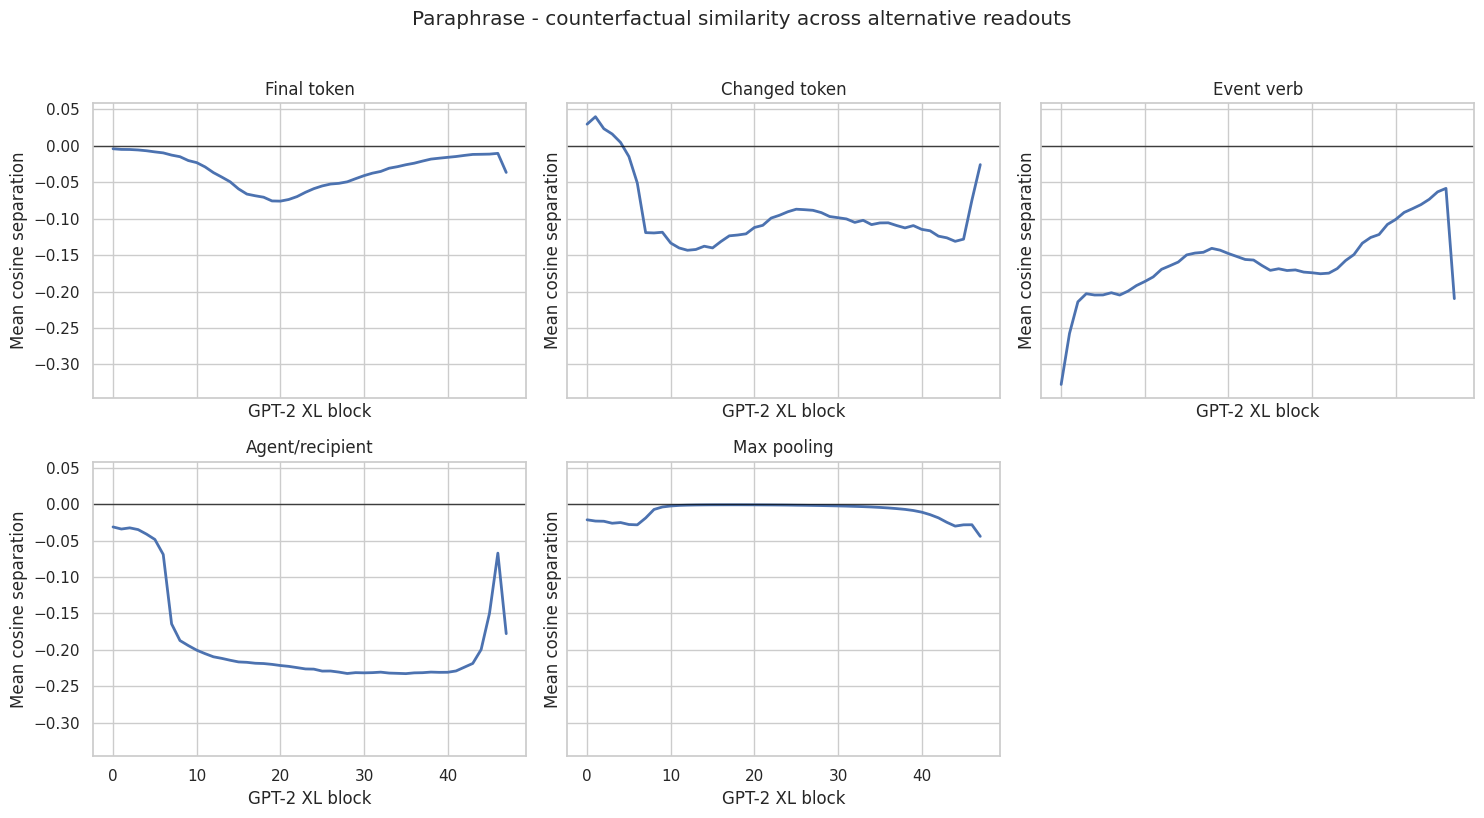

In [11]:
REPRESENTATIONS = ['final_token', 'changed_token', 'event_verb', 'agent_recipient', 'max_pool']
DISPLAY_NAMES = {
    'final_token': 'Final token',
    'changed_token': 'Changed token',
    'event_verb': 'Event verb',
    'agent_recipient': 'Agent/recipient',
    'max_pool': 'Max pooling',
}

def representation_curve(situations, representation: str) -> pd.DataFrame:
    rows = []
    for layer in range(N_LAYERS):
        paraphrase, counterfactual = [], []
        for situation in situations:
            base = readout_vector(situation, 'base', layer, representation)
            paraphrase.append(cosine(base, readout_vector(situation, 'paraphrase', layer, representation)))
            counterfactual.append(cosine(base, readout_vector(situation, 'counterfactual', layer, representation)))
        separation = np.subtract(paraphrase, counterfactual)
        rows.append({
            'representation': representation,
            'layer': layer,
            'paraphrase_similarity': np.mean(paraphrase),
            'counterfactual_similarity': np.mean(counterfactual),
            'separation': np.mean(separation),
            'separation_se': np.std(separation, ddof=1) / np.sqrt(len(separation)),
        })
    return pd.DataFrame(rows)

readout_scores = pd.concat([representation_curve(SITUATIONS, name) for name in REPRESENTATIONS], ignore_index=True)

summary_rows = []
for name, group in readout_scores.groupby('representation', sort=False):
    peak = group.loc[group.separation.abs().idxmax()]
    summary_rows.append({
        'representation': DISPLAY_NAMES[name],
        'mean_abs_separation': group.separation.abs().mean(),
        'largest_abs_separation': abs(peak.separation),
        'layer_of_largest_separation': int(peak.layer),
        'signed_separation_at_that_layer': peak.separation,
    })
readout_summary = pd.DataFrame(summary_rows).sort_values('mean_abs_separation', ascending=False)
display(readout_summary.style.format({
    'mean_abs_separation': '{:.4f}',
    'largest_abs_separation': '{:.4f}',
    'signed_separation_at_that_layer': '{:.4f}',
}))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, name in zip(axes.flat, REPRESENTATIONS):
    group = readout_scores.query('representation == @name')
    ax.plot(group.layer, group.separation, linewidth=2)
    ax.axhline(0, color='black', linewidth=1, alpha=0.7)
    ax.set_title(DISPLAY_NAMES[name])
    ax.set_xlabel('GPT-2 XL block')
    ax.set_ylabel('Mean cosine separation')
axes.flat[-1].axis('off')
fig.suptitle('Paraphrase - counterfactual similarity across alternative readouts', y=1.02)
fig.tight_layout()
plt.show()

# Positive values mean base-paraphrase pairs are more similar than base-counterfactual pairs.
# Interpret this only as a small-sample metric diagnostic; do not select a layer from it.


### Conclusion 3: Alternative representation diagnostic


The alternative readouts show that situation-related differences are much more visible at specific token positions than in whole-sentence pooled representations. Agent/recipient, event-verb, and changed-token representations showed the strongest separation, while final-token and max-pooled representations showed much weaker effects.

#### Findings by readout

- **Final token:** The final-token representation showed only weak separation between paraphrases and counterfactuals. The effect became somewhat stronger in the middle layers, but remained negative overall, so it did not support the predicted situation-score direction.

- **Changed token:** Looking directly at the token involved in the manipulation produced much stronger separation. This suggests that the model is sensitive to the changed information locally, even though the separation was still mostly negative.

- **Event verb:** Event-verb representations showed large differences between paraphrases and counterfactuals, especially in earlier and middle layers. This suggests that the representation of an action is affected by the surrounding situation, although the result again did not follow the expected positive situation-score pattern.

- **Agent/recipient:** Agent and recipient representations showed the strongest and most consistent separation across layers. This suggests that information about who is doing what to whom is especially sensitive to changes in the situation.

- **Max pooling:** Max-pooled whole-sentence representations showed very little separation across most layers. Like mean pooling, this suggests that combining information across the entire sentence can hide more localized semantic differences.

Overall, most separation scores were negative, meaning that the counterfactual sentences were often more similar to the original than the paraphrases were. This is likely influenced by a lexical-overlap confound: many counterfactuals preserve almost all of the original wording, while the paraphrases use substantially different wording. Therefore, these results cannot yet tell us whether GPT-2 XL is responding to changes in the underlying situation or simply to differences in surface-level wording.

### Next Step: Controlling for Lexical Similarity

The next experiment will test whether the negative separation is caused by differences in lexical overlap. I will create a more controlled set of situation triples where the paraphrase and counterfactual have approximately equal levels of wording and structural change relative to the original sentence.

I will then repeat the alternative-readout analysis using final-token, changed-token, event-verb, agent/recipient, and pooled representations. I will also measure lexical similarity directly as a control. If paraphrases become more similar than counterfactuals after controlling for wording, this would provide stronger evidence that the model is representing differences in the underlying situation rather than simply responding to shared words.

------
-----
-----